# Introduction to Pyro

In [ ]:
import pyro
import torch
from pyro import distributions as dist
import matplotlib.pyplot as plt
import numpy as np

import arviz as az
from pyro.infer import MCMC, NUTS, Predictive, EmpiricalMarginal
from pyro.infer.autoguide import init_to_mean, init_to_median, init_to_value
from pyro.infer.mcmc.util import summary

from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

In [182]:
seed = 2026
np.random.seed(seed)
torch.manual_seed(seed)
pyro.set_rng_seed(seed)
torch.use_deterministic_algorithms(True)


In [183]:
# Parameters
a = pyro.param("a", torch.tensor(1.0))
b = pyro.param("b", torch.tensor([1.0, 2.0]))
a, b

(tensor(1., requires_grad=True), tensor([1., 2.], requires_grad=True))

In [184]:
# Samples
c = dist.Normal(0, 1).sample((5,))
d = dist.Normal(0, 1).expand([2]).sample((5,))
c, d

(tensor([ 0.3655,  1.9065,  0.2169,  0.2963, -1.0160]),
 tensor([[-0.6064,  0.1744],
         [-0.6306, -0.0954],
         [ 0.3191, -1.4710],
         [ 0.2610,  0.2796],
         [ 0.3426, -0.6132]]))

In [185]:
e = pyro.sample("e", dist.Normal(0, 1))
f = pyro.sample("f", dist.Normal(0, 1).expand([2]))
e,f

(tensor(-1.0022), tensor([ 0.1142, -2.0875]))

In [186]:
true_p = 0.7
data = dist.Bernoulli(true_p).sample((100,))
data


tensor([0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
        0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
        0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0.,
        0., 1., 1., 1., 1., 1., 1., 1., 1., 0.])

# Beta distribution
$$p(x; \alpha, \beta) = k * x^{\alpha -1} (1-x)^{\beta -1}$$

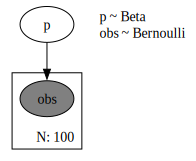

In [187]:
alpha_prior, beta_prior = 5.0, 1.0
def model(data):
    p = pyro.sample("p", dist.Beta(alpha_prior, beta_prior))
    with pyro.plate(f"N: {len(data)}", len(data)):
        pyro.sample("obs", dist.Bernoulli(p), obs=data)
        


pyro.render_model(model, model_args=(data,), render_distributions=True)

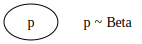

In [188]:
def guide(data):
    alpha = pyro.param("alpha", torch.tensor(alpha_prior), constraint=dist.constraints.positive)
    beta = pyro.param("beta", torch.tensor(beta_prior), constraint=dist.constraints.positive)
    pyro.sample("p", dist.Beta(alpha, beta))
    
pyro.render_model(guide, model_args=(data,), render_distributions=True)

In [ ]:


optimizer = Adam({"lr": 0.001})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

losses = []
for step in range(10000):
    loss = svi.step(data)
    losses.append(loss)

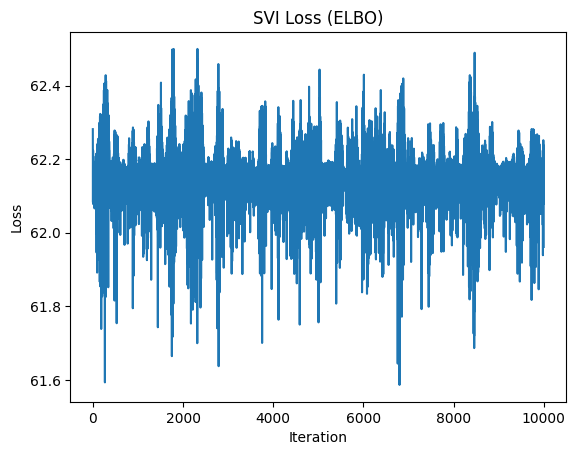

In [190]:
plt.plot(losses)
plt.title("SVI Loss (ELBO)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

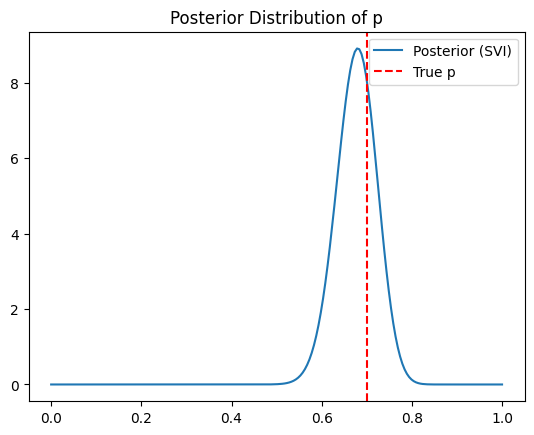

In [153]:
alpha = pyro.param("alpha").item()
beta = pyro.param("beta").item()

x = np.linspace(0, 1, 200)
posterior = dist.Beta(alpha, beta).log_prob(torch.tensor(x)).exp().numpy()

plt.plot(x, posterior, label="Posterior (SVI)")
plt.axvline(true_p, color='r', linestyle='--', label="True p")
plt.title("Posterior Distribution of p")
plt.legend()
plt.show()

In [154]:
from pyro.infer import MCMC, NUTS


nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples=1000, warmup_steps=200, num_chains=1)
mcmc.run(data)

samples = mcmc.get_samples()["p"].numpy()

Sample: 100%|██████████| 1200/1200 [00:02, 487.46it/s, step size=8.99e-01, acc. prob=0.935]


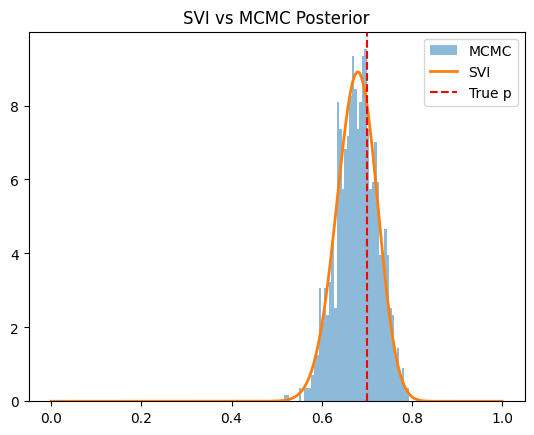

In [155]:
plt.hist(samples, bins=50, density=True, alpha=0.5, label="MCMC")

plt.plot(x, posterior, label="SVI", linewidth=2)
plt.axvline(true_p, color='r', linestyle='--', label="True p")

plt.legend()
plt.title("SVI vs MCMC Posterior")
plt.show()

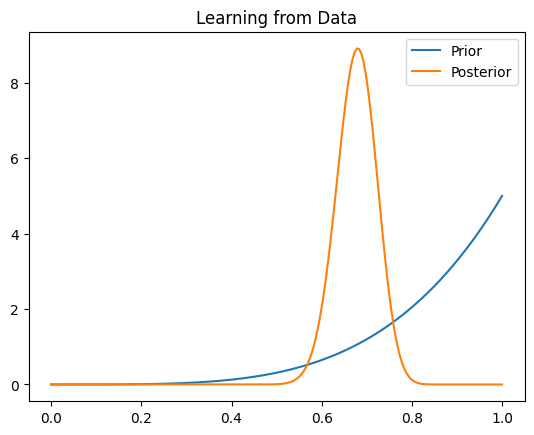

In [156]:
prior = dist.Beta(alpha_prior, beta_prior).log_prob(torch.tensor(x)).exp().numpy()

plt.plot(x, prior, label="Prior")
plt.plot(x, posterior, label="Posterior")
plt.legend()
plt.title("Learning from Data")
plt.show()

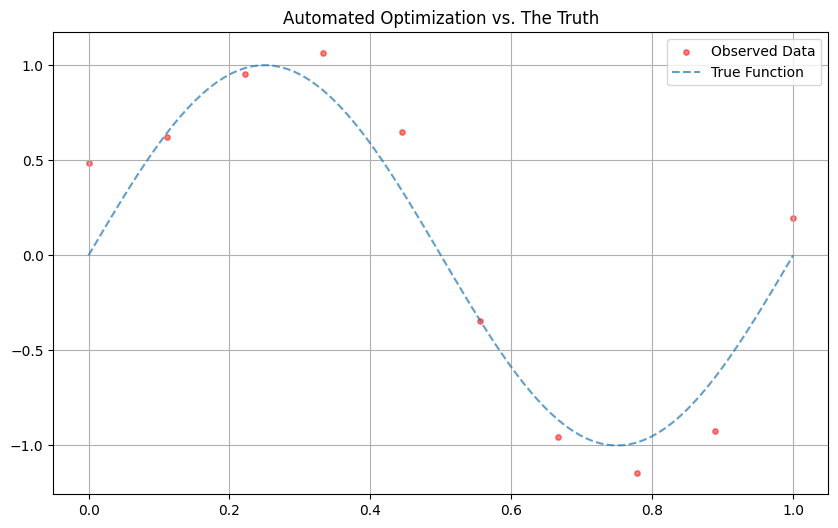

In [157]:
x = torch.linspace(0, 1, 10)
x_plot = torch.linspace(0, 1, 100)
y = torch.sin(2 * np.pi * x) 
y_true = torch.sin(2 * np.pi * x_plot)
noise = 0.2 * torch.randn_like(x)
y_obs = y + noise

plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data")
plt.plot(x_plot, y_true, linestyle='--', alpha=0.7, label="True Function")

plt.title("Automated Optimization vs. The Truth")
plt.legend()
plt.grid(True)
plt.show()


In [158]:
# f(x; \theta) = \sum_{i=0}^{9} \theta_i x^i
def custom_function(x, coeff_poly):
    output =    coeff_poly[0] +\
                coeff_poly[1] * x +\
                coeff_poly[2] * x**2 +\
                coeff_poly[3] * x**3 +\
                coeff_poly[4] * x**4 +\
                coeff_poly[5] * x**5 +\
                coeff_poly[6] * x**6 +\
                coeff_poly[7] * x**7 +\
                coeff_poly[8] * x**8 +\
                coeff_poly[9] * x**9
    return output


In [159]:
def model_poly(x, data):
    # We place a prior over the coefficients of the polynomial
    coeffs = pyro.sample("coeffs", dist.Normal(0, 10).expand([10]))
   
    # coeff_0 = pyro.sample("coeff_0", dist.Normal(0, 10))
    # coeff_1 = pyro.sample("coeff_1", dist.Normal(0, 10))
    # coeff_2 = pyro.sample("coeff_2", dist.Normal(0, 10))
    # coeff_3 = pyro.sample("coeff_3", dist.Normal(0, 10))
    # coeff_4 = pyro.sample("coeff_4", dist.Normal(0, 10))
    # coeff_5 = pyro.sample("coeff_5", dist.Normal(0, 10))
    # coeff_6 = pyro.sample("coeff_6", dist.Normal(0, 10))
    # coeff_7 = pyro.sample("coeff_7", dist.Normal(0, 10))
    # coeff_8 = pyro.sample("coeff_8", dist.Normal(0, 10))
    # coeff_9 = pyro.sample("coeff_9", dist.Normal(0, 10))
    # coeffs = torch.stack([coeff_0, coeff_1, coeff_2, coeff_3, coeff_4, coeff_5, coeff_6, coeff_7, coeff_8, coeff_9])
    
    y_pred =    custom_function(x, coeffs)
                
    with pyro.plate("data", len(data)):
        pyro.sample("obs", dist.Normal(y_pred, 0.2), obs=data)
pyro.render_model(model_poly, model_args=(x, y_obs,), render_distributions=True) # Args shoulb be a tuple

prior = Predictive(model_poly,num_samples=1000)(x,y_obs)
data_post = az.from_pyro(prior=prior)

In [160]:
from pyro.infer import MCMC, NUTS


nuts_kernel = NUTS(model_poly)
mcmc = MCMC(nuts_kernel, num_samples=200, warmup_steps=200, num_chains=1)
mcmc.run(x, y_obs)

samples = mcmc.get_samples()

Warmup:  46%|████▌     | 184/400 [01:20,  2.38it/s, step size=1.51e-02, acc. prob=0.788]

KeyboardInterrupt: 

array([[<Axes: title={'center': 'coeffs\n0'}>,
        <Axes: title={'center': 'coeffs\n1'}>,
        <Axes: title={'center': 'coeffs\n2'}>],
       [<Axes: title={'center': 'coeffs\n3'}>,
        <Axes: title={'center': 'coeffs\n4'}>,
        <Axes: title={'center': 'coeffs\n5'}>],
       [<Axes: title={'center': 'coeffs\n6'}>,
        <Axes: title={'center': 'coeffs\n7'}>,
        <Axes: title={'center': 'coeffs\n8'}>],
       [<Axes: title={'center': 'coeffs\n9'}>, <Axes: >, <Axes: >]],
      dtype=object)

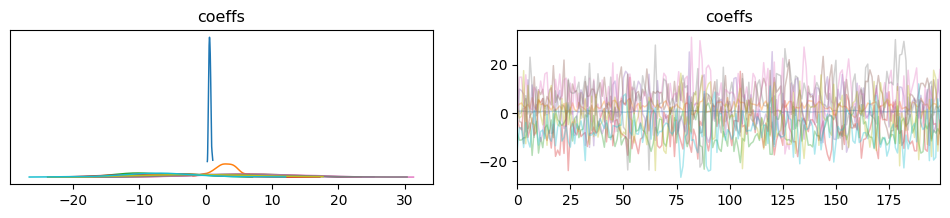

<Figure size 800x1000 with 0 Axes>

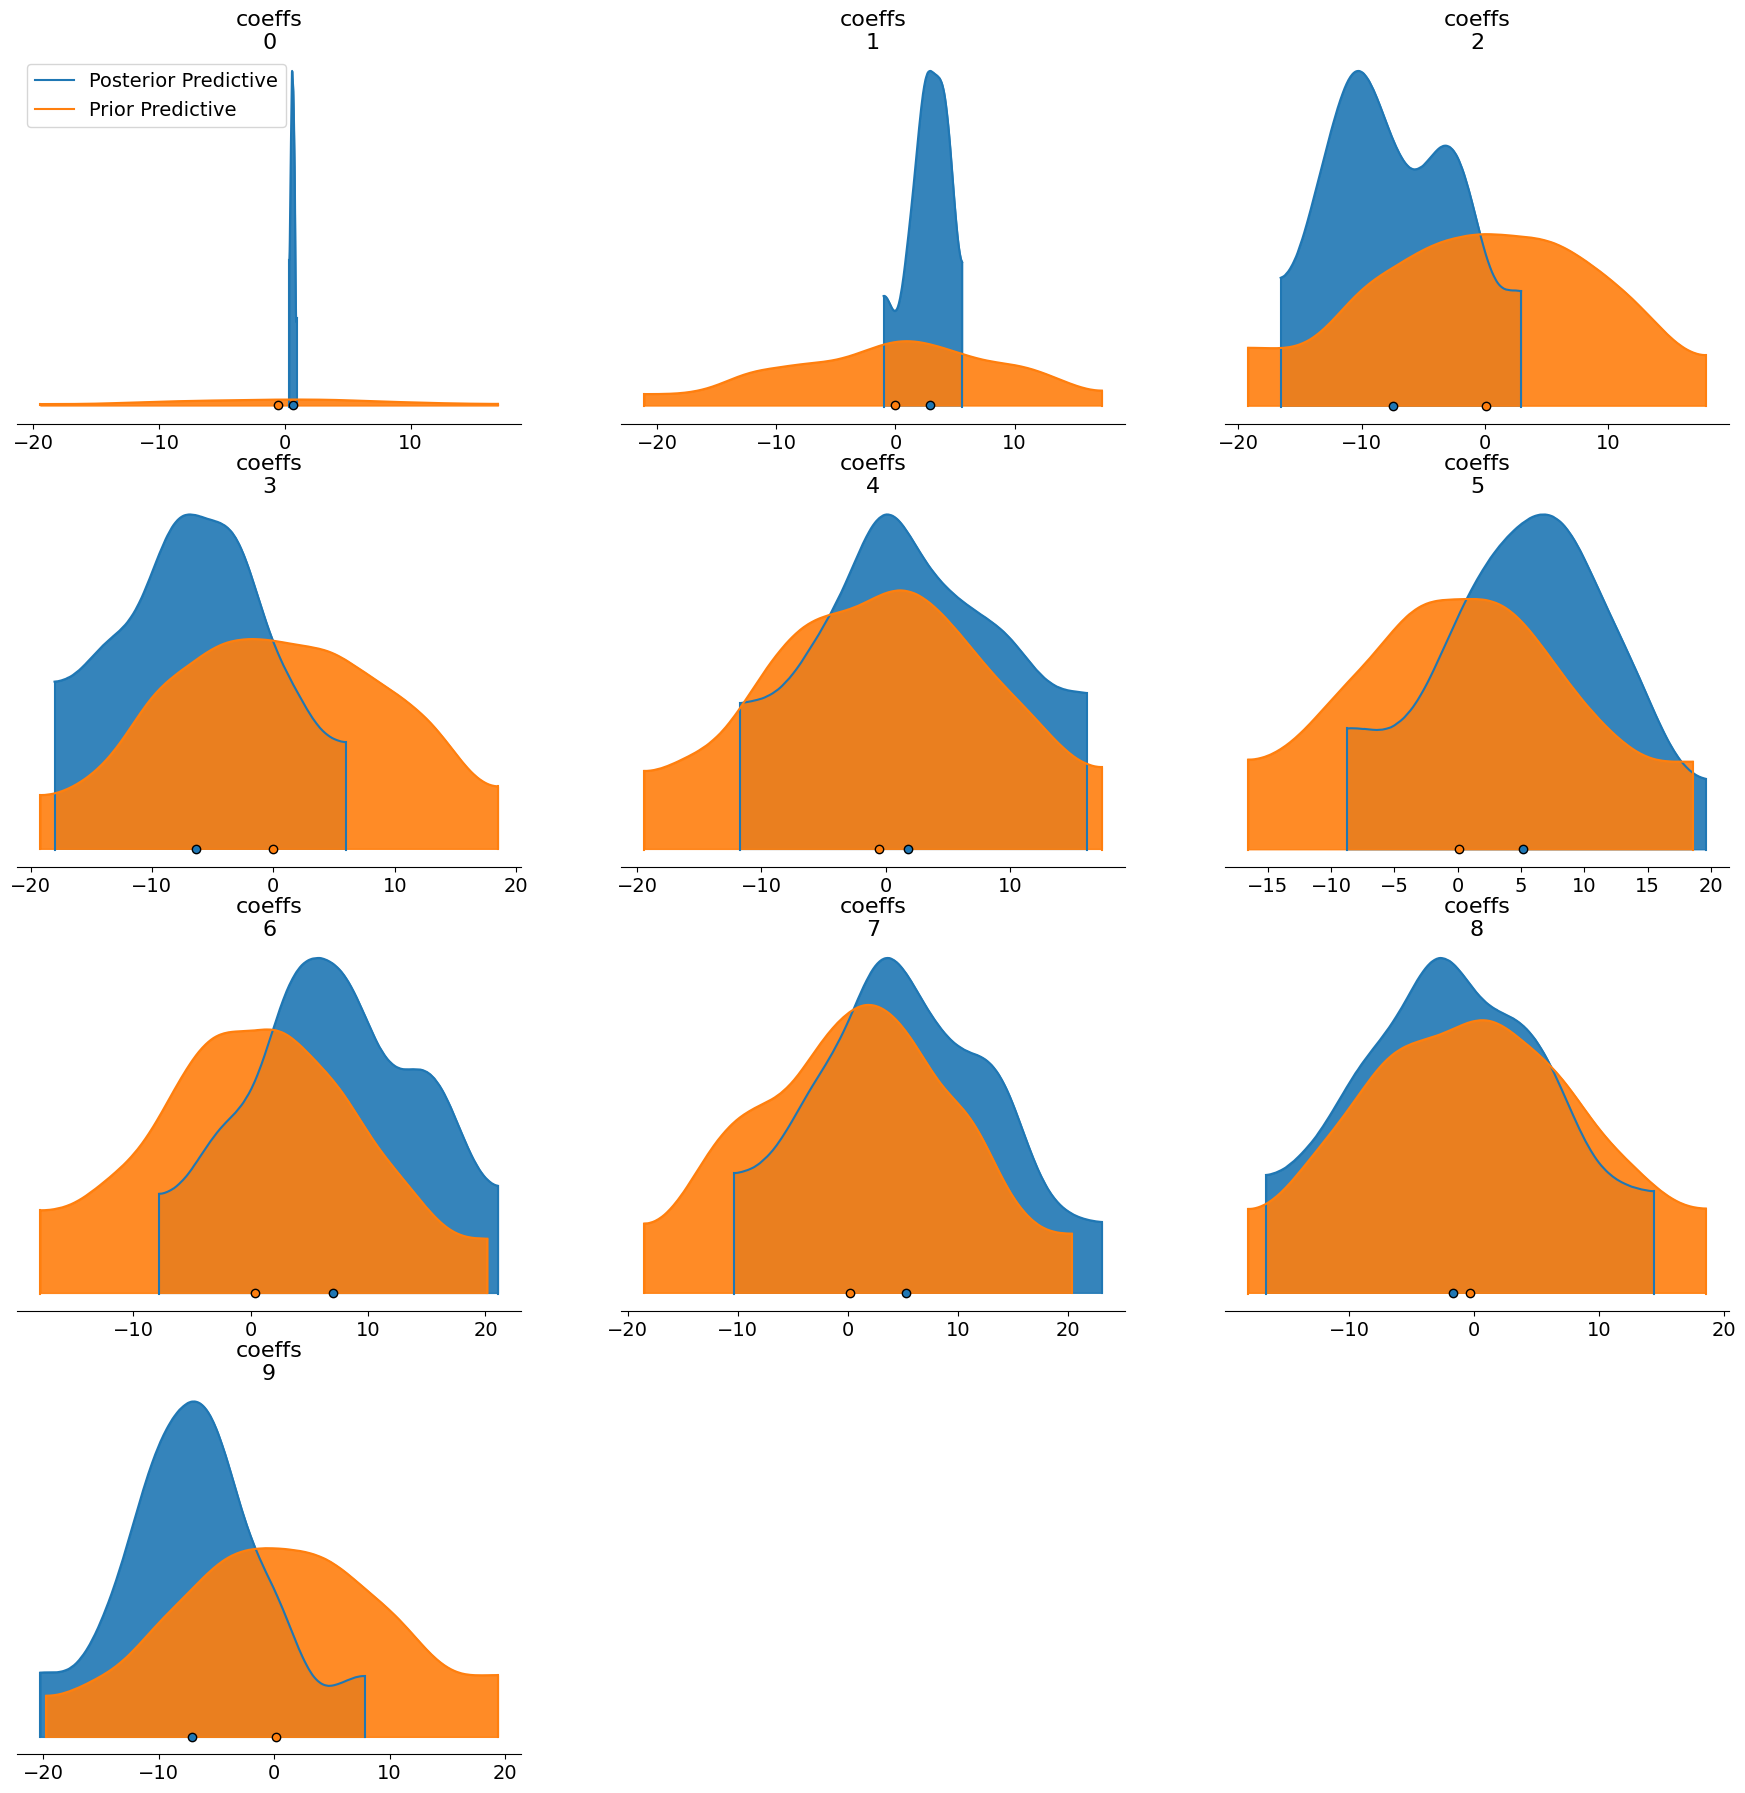

In [ ]:
posterior_predictive = Predictive(model_poly, samples)(x, y_obs)

data_post = az.from_pyro(posterior=mcmc, prior=prior, posterior_predictive=posterior_predictive)
az.plot_trace(data_post)

plt.figure(figsize=(8,10))
az.plot_density(
data=[data_post.posterior, data_post.prior],
shade=.9,
# bw=0.006,  # increase bandwidth for smoother curve
var_names=['coeffs'],
data_labels=["Posterior Predictive", "Prior Predictive"],
)


In [ ]:
samples_mean = samples["coeffs"].mean(axis=0)
samples_mean

tensor([ 0.6326,  2.8703, -7.4135, -6.3863,  1.8269,  5.1345,  7.0134,  5.2637,
        -1.6959, -7.1221])

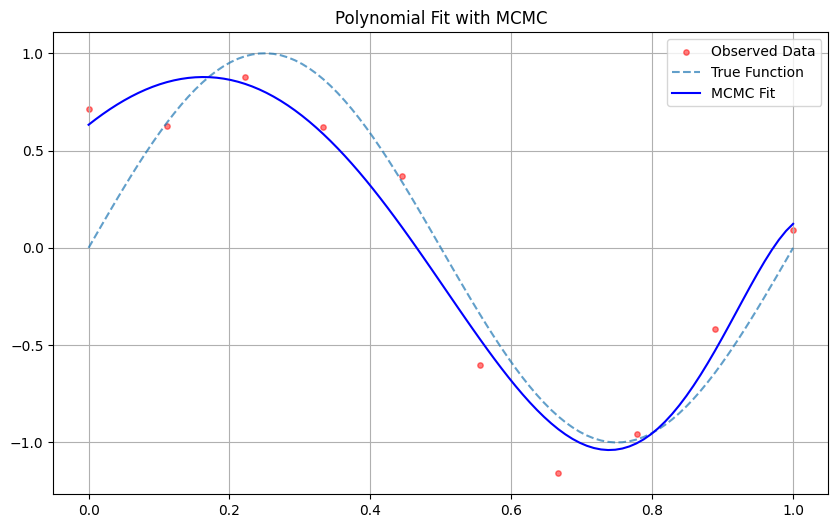

In [ ]:
coeffs_samples = samples_mean
y_mean =    custom_function(x_plot, coeffs_samples)
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='red', s=15, alpha=0.5, label="Observed Data")
plt.plot(x_plot, y_true, linestyle='--', alpha=0.7, label="True Function")
plt.plot(x_plot, y_mean, color='blue', label="MCMC Fit")
plt.title("Polynomial Fit with MCMC")
plt.legend()
plt.grid(True)
plt.show()